# Dependencies

In [2]:
#!pip install librosa soundfile matplotlib numpy pandas scikit-learn seaborn
 

# Imports

In [3]:
# --- Core Audio Processing ---
import librosa
import librosa.display
import soundfile as sf
 
# --- Data & Math ---
import numpy as np
import pandas as pd
 
# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
 
# --- Machine Learning ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
 
# --- File / System ---
import os
import glob
import zipfile
import warnings
warnings.filterwarnings('ignore')
 
# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")

 

# Download the Orca Speak

In [4]:
BASE_DIR = "/Volumes/Preston's 256gb/Datasets/clips"

# Support both folder conventions: val/ and validation/
val_dir = "val" if os.path.isdir(os.path.join(BASE_DIR, "val")) else "validation"

srkw_train = sorted(glob.glob(os.path.join(BASE_DIR, "train", "srkw", "*.wav")))
srkw_test  = sorted(glob.glob(os.path.join(BASE_DIR, "test", "srkw", "*.wav")))
srkw_val   = sorted(glob.glob(os.path.join(BASE_DIR, val_dir, "srkw", "*.wav")))

print(f"SRKW train: {len(srkw_train)}")
print(f"SRKW test:  {len(srkw_test)}")
print(f"SRKW val ({val_dir}): {len(srkw_val)}")
print(f"Total:      {len(srkw_train) + len(srkw_test) + len(srkw_val)}")

if len(srkw_val) == 0:
    raise ValueError(
        f"No validation clips found in {os.path.join(BASE_DIR, val_dir, 'srkw')}. "
        "Check BASE_DIR and split folder names."
    )

SRKW train: 4000
SRKW test:  400
SRKW val (val): 400
Total:      4800


# Load & Resample Data

In [5]:
TARGET_SR = 22050

def load_clip(filepath, target_sr=TARGET_SR):
    """Load a WAV file and resample to the target sample rate."""
    y, sr = librosa.load(filepath, sr=target_sr)
    return y, target_sr

# Sanity check
y_test, sr_test = load_clip(srkw_train[0])
print(f"Sample clip: {os.path.basename(srkw_train[0])}")
print(f"  Duration:    {len(y_test)/sr_test:.2f}s")
print(f"  Sample rate: {sr_test} Hz")
print(f"  Samples:     {len(y_test)}")
print(f"  Amplitude:   [{y_test.min():.4f}, {y_test.max():.4f}]")

Sample clip: clip_0.wav
  Duration:    3.00s
  Sample rate: 22050 Hz
  Samples:     66150
  Amplitude:   [-0.0311, 0.0353]


# Visualize the Waveform

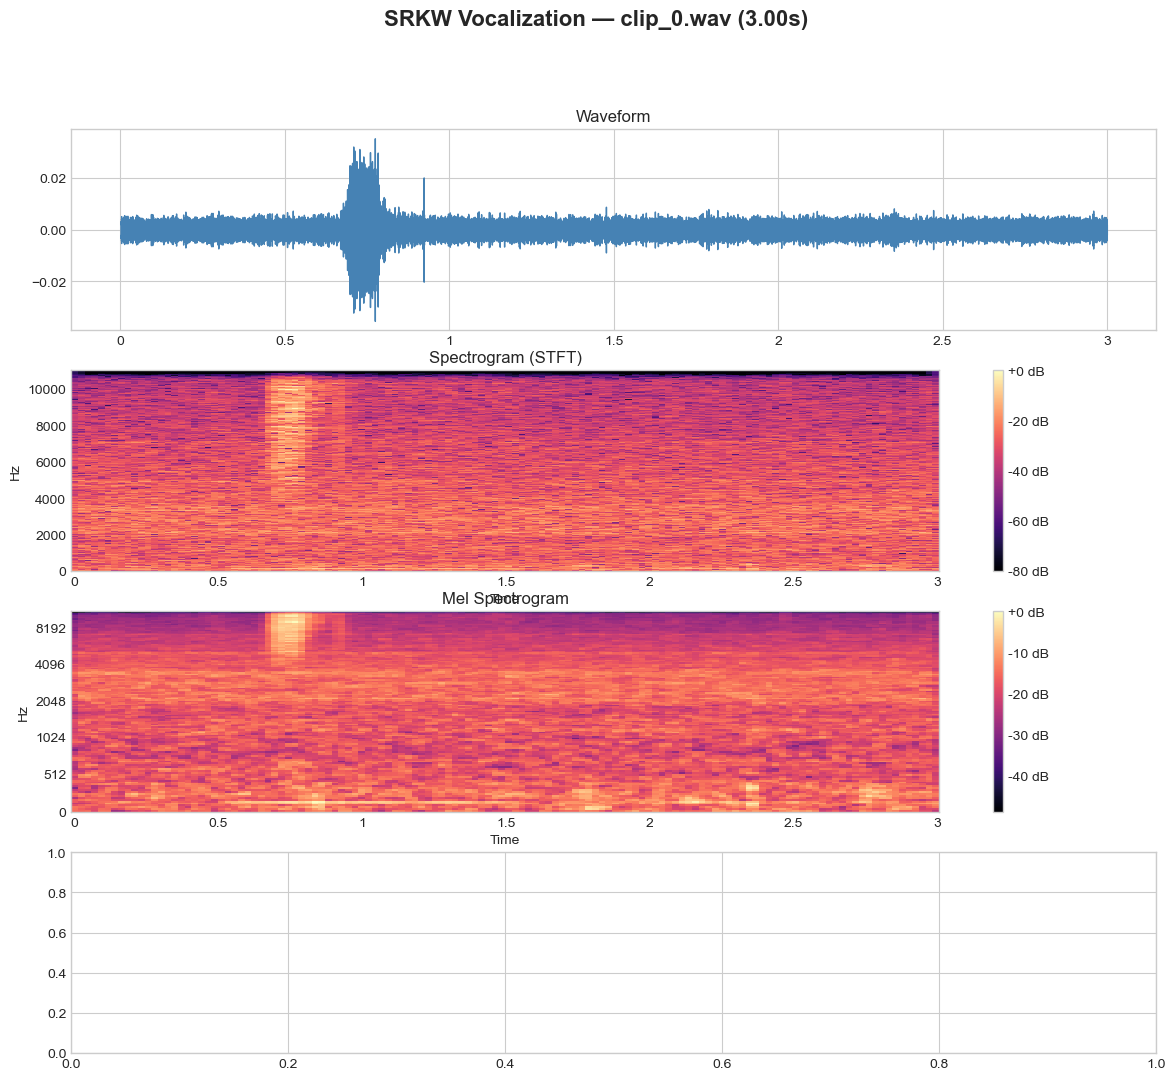

In [6]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — VISUALIZE: WAVEFORM + SPECTROGRAM FOR A SINGLE CLIP           ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

def plot_clip_overview(filepath, clip_label=None):
    """Plot waveform, spectrogram, mel spectrogram, and chromagram for one clip."""
    y, sr = load_clip(filepath)
    duration = len(y) / sr

    if clip_label is None:
        clip_label = os.path.basename(filepath)

    fig, axes = plt.subplots(4, 1, figsize=(14, 12))
    fig.suptitle(f"SRKW Vocalization — {clip_label} ({duration:.2f}s)",
                 fontsize=16, fontweight='bold', y=0.98)

    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[0], color='steelblue')
    axes[0].set_title("Waveform", fontsize=12)
    axes[0].set_xlabel("")

    # Spectrogram (STFT)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img1 = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz',
                                     ax=axes[1], cmap='magma')
    axes[1].set_title("Spectrogram (STFT)", fontsize=12)
    axes[1].set_ylim(0, sr // 2)
    fig.colorbar(img1, ax=axes[1], format='%+2.0f dB')

    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img2 = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel',
                                     ax=axes[2], cmap='magma')
    axes[2].set_title("Mel Spectrogram", fontsize=12)
    fig.colorbar(img2, ax=axes[2], format='%+2.0f dB')


plot_clip_overview(srkw_train[0])

# Visualize Grid of SRKW Spectrogram

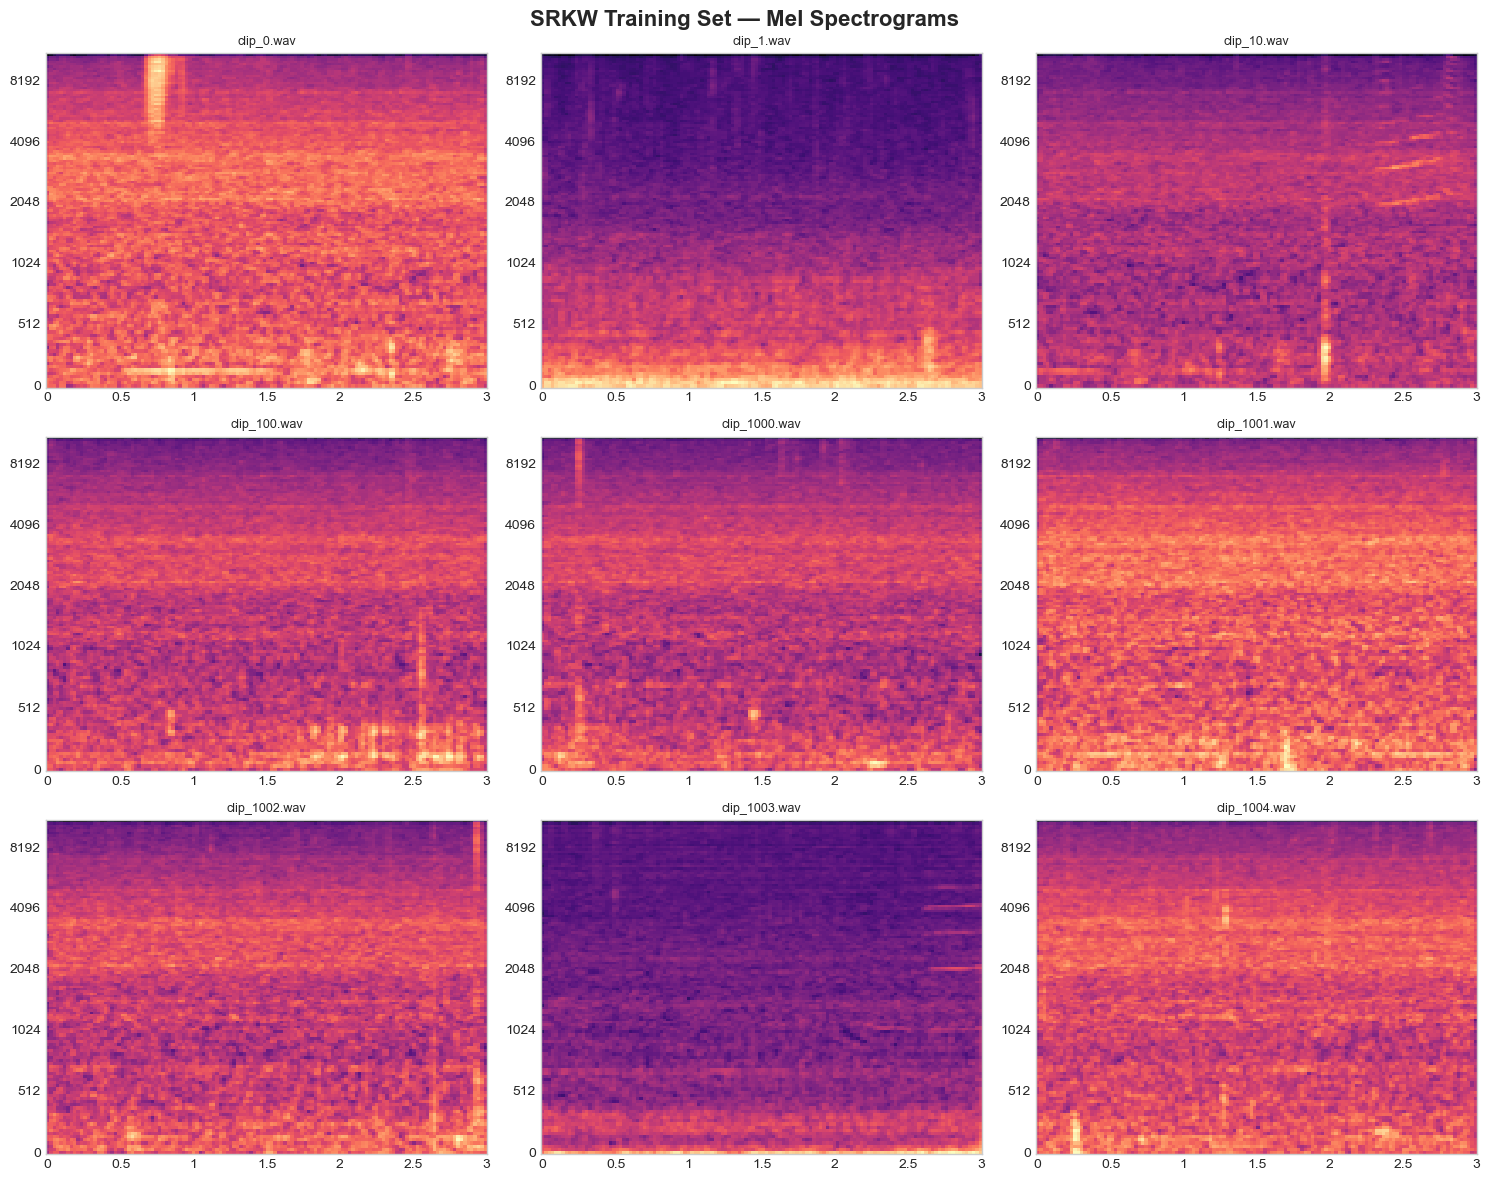

In [7]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — VISUALIZE: GRID OF SRKW SPECTROGRAMS                          ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

def plot_spectrogram_grid(file_list, title="Mel Spectrograms", n_clips=9, n_cols=3):
    """Show mel spectrograms for multiple clips in a grid."""
    n_clips = min(n_clips, len(file_list))
    n_rows = (n_clips + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for i in range(n_clips):
        y, sr = load_clip(file_list[i])
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_dB = librosa.power_to_db(S, ref=np.max)

        librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel',
                                  ax=axes[i], cmap='magma')
        axes[i].set_title(os.path.basename(file_list[i]), fontsize=9)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    for j in range(n_clips, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_spectrogram_grid(srkw_train, title="SRKW Training Set — Mel Spectrograms", n_clips=9)

# Feature Extraction

In [8]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — FEATURE EXTRACTION FUNCTION                                   ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

def extract_features(y, sr):
    """
    Extract a comprehensive feature vector from a single audio clip.
    Returns a dict of scalar features (mean/std aggregations over time).
    """
    features = {}

    # MFCCs (13 coefficients)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfccs[i])
        features[f"mfcc_{i+1}_std"]  = np.std(mfccs[i])

    # Delta MFCCs
    delta_mfccs = librosa.feature.delta(mfccs)
    for i in range(13):
        features[f"delta_mfcc_{i+1}_mean"] = np.mean(delta_mfccs[i])
        features[f"delta_mfcc_{i+1}_std"]  = np.std(delta_mfccs[i])

    # Spectral Centroid
    cent = librosa.feature.spectral_centroid(y=y, sr=sr)
    features["spectral_centroid_mean"] = np.mean(cent)
    features["spectral_centroid_std"]  = np.std(cent)

    # Spectral Bandwidth
    bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features["spectral_bandwidth_mean"] = np.mean(bw)
    features["spectral_bandwidth_std"]  = np.std(bw)

    # Spectral Rolloff
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features["spectral_rolloff_mean"] = np.mean(rolloff)
    features["spectral_rolloff_std"]  = np.std(rolloff)

    # Spectral Contrast
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    for i in range(contrast.shape[0]):
        features[f"spectral_contrast_{i+1}_mean"] = np.mean(contrast[i])

    # Spectral Flatness
    flatness = librosa.feature.spectral_flatness(y=y)
    features["spectral_flatness_mean"] = np.mean(flatness)
    features["spectral_flatness_std"]  = np.std(flatness)

    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features["zcr_mean"] = np.mean(zcr)
    features["zcr_std"]  = np.std(zcr)

    # RMS Energy
    rms = librosa.feature.rms(y=y)
    features["rms_mean"] = np.mean(rms)
    features["rms_std"]  = np.std(rms)

    # Chroma (12 pitch classes)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    for i in range(12):
        features[f"chroma_{i+1}_mean"] = np.mean(chroma[i])

    return features

# Quick test
y_tmp, sr_tmp = load_clip(srkw_train[0])
test_feats = extract_features(y_tmp, sr_tmp)
print(f"Features per clip: {len(test_feats)}")

Features per clip: 83


# Feature Matrix from Training Set

In [9]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — BUILD FEATURE MATRIX FROM TRAINING SET                        ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

# Extract features from the training split.
# If your train set is very large, adjust N_SAMPLES to control runtime.
# Set to None to use ALL training clips.

N_SAMPLES = None  # e.g., 500 for faster iteration, None for all

np.random.seed(42)

if N_SAMPLES and N_SAMPLES < len(srkw_train):
    indices = np.random.choice(len(srkw_train), size=N_SAMPLES, replace=False)
    train_subset = [srkw_train[i] for i in sorted(indices)]
else:
    train_subset = srkw_train

print(f"Extracting features from {len(train_subset)} training clips...")

feature_list = []
for i, fp in enumerate(train_subset):
    y, sr = load_clip(fp)
    feats = extract_features(y, sr)
    feats["filename"] = os.path.basename(fp)
    feats["split"] = "train"
    feature_list.append(feats)

    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{len(train_subset)} done")

df_train = pd.DataFrame(feature_list)
print(f"\nTraining feature matrix: {df_train.shape}")
df_train.head()

Extracting features from 4000 training clips...
  100/4000 done
  200/4000 done
  300/4000 done
  400/4000 done
  500/4000 done
  600/4000 done
  700/4000 done
  800/4000 done
  900/4000 done
  1000/4000 done
  1100/4000 done
  1200/4000 done
  1300/4000 done
  1400/4000 done
  1500/4000 done
  1600/4000 done
  1700/4000 done
  1800/4000 done
  1900/4000 done
  2000/4000 done
  2100/4000 done
  2200/4000 done
  2300/4000 done
  2400/4000 done
  2500/4000 done
  2600/4000 done
  2700/4000 done
  2800/4000 done
  2900/4000 done
  3000/4000 done
  3100/4000 done
  3200/4000 done
  3300/4000 done
  3400/4000 done
  3500/4000 done
  3600/4000 done
  3700/4000 done
  3800/4000 done
  3900/4000 done
  4000/4000 done

Training feature matrix: (4000, 85)


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,chroma_5_mean,chroma_6_mean,chroma_7_mean,chroma_8_mean,chroma_9_mean,chroma_10_mean,chroma_11_mean,chroma_12_mean,filename,split
0,-410.382141,12.222379,21.829742,11.875345,-18.376360,10.980821,26.143272,6.981506,-0.631943,5.095131,...,0.714165,0.791472,0.653847,0.637667,0.771052,0.775953,0.619800,0.685280,clip_0.wav,train
1,-426.845490,7.893437,134.808807,10.257611,40.701576,5.671735,22.648193,4.130889,11.314384,4.815161,...,0.765141,0.824017,0.784310,0.712864,0.652376,0.647860,0.660629,0.624123,clip_1.wav,train
2,-410.454315,9.805301,25.481348,7.782793,-20.971838,5.719264,28.083513,4.594727,-1.676616,3.651825,...,0.648665,0.734472,0.718486,0.655991,0.707252,0.721008,0.593384,0.627562,clip_10.wav,train
3,-423.816467,8.645416,28.488728,8.319483,-17.709864,5.936512,35.399075,5.219229,2.048654,4.554041,...,0.722269,0.802724,0.646646,0.617247,0.751922,0.755687,0.613002,0.643472,clip_100.wav,train
4,-423.296509,9.355770,22.898760,5.405802,-18.517326,6.266318,33.102062,4.097182,1.702821,4.010292,...,0.731736,0.796122,0.607068,0.681704,0.802981,0.686748,0.600265,0.677727,clip_1000.wav,train


# Build Feature Matrix from Test + Validation

In [10]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — BUILD FEATURE MATRIX FROM TEST + VALIDATION SETS              ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

def extract_split(file_list, split_name):
    """Extract features from an entire split and return a DataFrame."""
    rows = []
    for i, fp in enumerate(file_list):
        y, sr = load_clip(fp)
        feats = extract_features(y, sr)
        feats["filename"] = os.path.basename(fp)
        feats["split"] = split_name
        rows.append(feats)

        if (i + 1) % 100 == 0:
            print(f"  {split_name}: {i + 1}/{len(file_list)} done")
    return pd.DataFrame(rows)

print(f"Extracting test set ({len(srkw_test)} clips)...")
df_test = extract_split(srkw_test, "test")

print(f"Extracting validation set ({len(srkw_val)} clips)...")
df_val = extract_split(srkw_val, "val")

if df_val.empty:
    raise ValueError(
        "df_val is empty after extraction. Check validation file paths in the download/split cell."
    )

# Combined view (keeps split column so you can filter later)
df_all = pd.concat([df_train, df_test, df_val], ignore_index=True)
print(f"\nCombined feature matrix: {df_all.shape}")
print(f"Split distribution:\n{df_all['split'].value_counts().to_string()}")

Extracting test set (400 clips)...
  test: 100/400 done
  test: 200/400 done
  test: 300/400 done
  test: 400/400 done
Extracting validation set (400 clips)...
  val: 100/400 done
  val: 200/400 done
  val: 300/400 done
  val: 400/400 done

Combined feature matrix: (4800, 85)
Split distribution:
split
train    4000
test      400
val       400


# PCA Step 1: Dimensionality Reduction 

In [11]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — PCA: DIMENSIONALITY REDUCTION (FIT ON TRAIN)                 ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

# Important: fit the scaler and PCA on training data only,
# then transform test/val with the same fit. This prevents data leakage.


meta_cols = {"filename", "split"}
feature_cols = [c for c in df_train.columns if c not in meta_cols]
def get_X(df, name):
    missing = [c for c in feature_cols if c not in df.columns]
    if len(missing) == len(feature_cols):
        raise ValueError(
            f"{name} has completely different columns from train.\n"
            f"{name} first columns: {df.columns[:10].tolist()}\n"
            f"train first features: {feature_cols[:10]}"
        )
    if missing:
        print(f"{name}: missing {len(missing)} feature columns; filling with 0.0")
    return df.reindex(columns=feature_cols, fill_value=0.0).values
X_train = get_X(df_train, "df_train")
X_test  = get_X(df_test, "df_test")
X_val   = get_X(df_val, "df_val")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_val_scaled   = scaler.transform(X_val)
pca_full = PCA(n_components=0.95)
X_train_pca = pca_full.fit_transform(X_train_scaled)
X_test_pca  = pca_full.transform(X_test_scaled)
X_val_pca   = pca_full.transform(X_val_scaled)

# Scree Plot

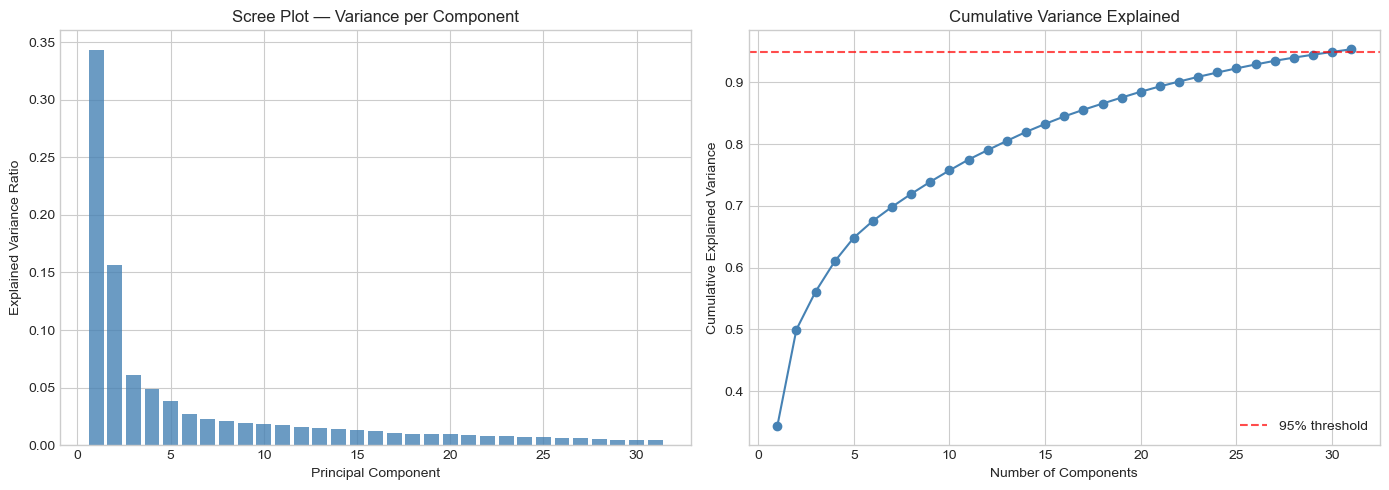

In [12]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — SCREE PLOT                                                   ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_, color='steelblue', alpha=0.8)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")
ax1.set_title("Scree Plot — Variance per Component")

cumulative = np.cumsum(pca_full.explained_variance_ratio_)
ax2.plot(range(1, len(cumulative) + 1), cumulative, 'o-', color='steelblue')
ax2.axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Explained Variance")
ax2.set_title("Cumulative Variance Explained")
ax2.legend()

plt.tight_layout()
plt.show()

# PCA 2D Scatter + K-Means Clustering

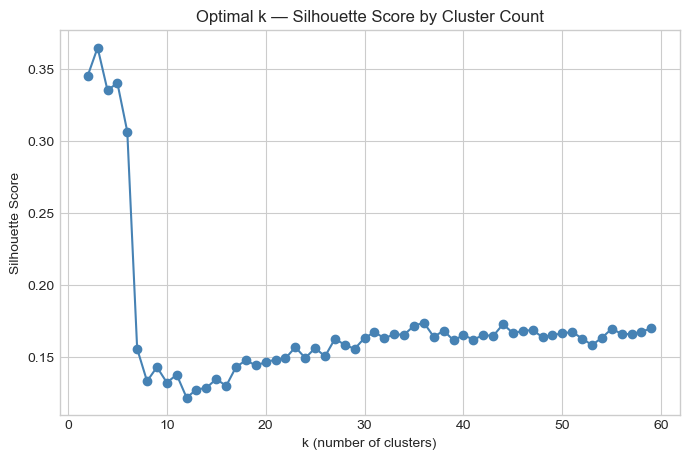

  k=2: silhouette=0.345
  k=3: silhouette=0.365
  k=4: silhouette=0.335
  k=5: silhouette=0.340
  k=6: silhouette=0.307
  k=7: silhouette=0.156
  k=8: silhouette=0.133
  k=9: silhouette=0.143
  k=10: silhouette=0.133
  k=11: silhouette=0.138
  k=12: silhouette=0.122
  k=13: silhouette=0.128
  k=14: silhouette=0.129
  k=15: silhouette=0.135
  k=16: silhouette=0.130
  k=17: silhouette=0.143
  k=18: silhouette=0.148
  k=19: silhouette=0.144
  k=20: silhouette=0.147
  k=21: silhouette=0.148
  k=22: silhouette=0.149
  k=23: silhouette=0.157
  k=24: silhouette=0.150
  k=25: silhouette=0.157
  k=26: silhouette=0.151
  k=27: silhouette=0.163
  k=28: silhouette=0.159
  k=29: silhouette=0.156
  k=30: silhouette=0.164
  k=31: silhouette=0.167
  k=32: silhouette=0.163
  k=33: silhouette=0.166
  k=34: silhouette=0.166
  k=35: silhouette=0.172
  k=36: silhouette=0.174
  k=37: silhouette=0.164
  k=38: silhouette=0.169
  k=39: silhouette=0.162
  k=40: silhouette=0.166
  k=41: silhouette=0.162
  k=42: 

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
K_range = range(2, 60)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    sil_scores.append(silhouette_score(X_train_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), sil_scores, 'o-', color='steelblue')
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette Score")
plt.title("Optimal k — Silhouette Score by Cluster Count")
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"  k={k}: silhouette={s:.3f}")

In [14]:
sil_by_ncomp = []
comp_range = [i for i in range(2, 60)]

best_k = 10  # replace with your best k from the silhouette sweep

for n in comp_range:
    pca_temp = PCA(n_components=n)
    X_temp = pca_temp.fit_transform(X_train_scaled)
    km_temp = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels = km_temp.fit_predict(X_temp)
    sil = silhouette_score(X_temp, labels)
    var_explained = sum(pca_temp.explained_variance_ratio_)
    sil_by_ncomp.append((n, sil, var_explained))
    print(f"  n_components={n:2d} | variance={var_explained:.3f} | silhouette={sil:.3f}")



  n_components= 2 | variance=0.500 | silhouette=0.481
  n_components= 3 | variance=0.561 | silhouette=0.395
  n_components= 4 | variance=0.610 | silhouette=0.388
  n_components= 5 | variance=0.649 | silhouette=0.378
  n_components= 6 | variance=0.676 | silhouette=0.299
  n_components= 7 | variance=0.699 | silhouette=0.292
  n_components= 8 | variance=0.720 | silhouette=0.255
  n_components= 9 | variance=0.739 | silhouette=0.234
  n_components=10 | variance=0.758 | silhouette=0.229
  n_components=11 | variance=0.775 | silhouette=0.207
  n_components=12 | variance=0.791 | silhouette=0.216
  n_components=13 | variance=0.805 | silhouette=0.212
  n_components=14 | variance=0.820 | silhouette=0.188
  n_components=15 | variance=0.833 | silhouette=0.187
  n_components=16 | variance=0.845 | silhouette=0.153
  n_components=17 | variance=0.856 | silhouette=0.185
  n_components=18 | variance=0.866 | silhouette=0.168
  n_components=19 | variance=0.876 | silhouette=0.163
  n_components=20 | variance

Cluster sizes (train):
0     100
1     135
2      67
3     127
4      58
5     131
6      88
7      62
8     220
9     122
10    132
11     40
12    102
13    243
14     74
15    170
16     26
17     76
18     49
19    103
20    123
21    152
22     88
23     55
24    103
25     45
26    192
27     98
28     52
29    183
30    122
31     88
32     70
33     77
34     33
35    138
36     32
37     38
38     51
39    135
Name: count, dtype: int64
Silhouette score (train, k=3): 0.165


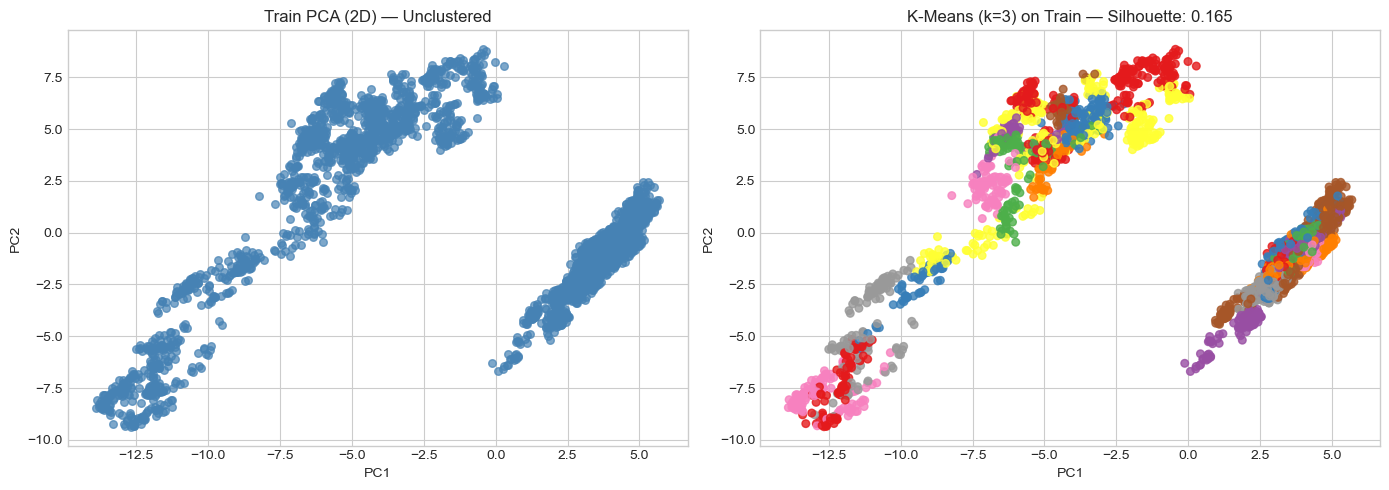

In [15]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — PCA 2D SCATTER + K-MEANS CLUSTERING                           ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

# 2D PCA fit on training (scaled) features
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

# K-Means on the full scaled training features (not PCA-reduced)
kmeans = KMeans(n_clusters=40, random_state=411, n_init=10)
cluster_labels_train = kmeans.fit_predict(X_train_scaled)

sil_train = silhouette_score(X_train_scaled, cluster_labels_train)

# Cluster sizes
cluster_sizes = pd.Series(cluster_labels_train).value_counts().sort_index()
print("Cluster sizes (train):")
print(cluster_sizes)
print(f"Silhouette score (train, k=3): {sil_train:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Unclustered scatter
ax1.scatter(X_train_2d[:, 0], X_train_2d[:, 1], color='steelblue', alpha=0.7, s=30)
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_title("Train PCA (2D) — Unclustered")

# Clustered scatter
sc = ax2.scatter(
    X_train_2d[:, 0], X_train_2d[:, 1],
    c=cluster_labels_train, cmap='Set1', alpha=0.8, s=30
)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_title(f"K-Means (k=3) on Train — Silhouette: {sil_train:.3f}")

plt.tight_layout()
plt.show()

In [16]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12b — INTERACTIVE 3D PCA (Plotly)                                   ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

import plotly.express as px

pca_3d = PCA(n_components=3)
X_train_3d = pca_3d.fit_transform(X_train_scaled)

ev = pca_3d.explained_variance_ratio_
cum_var = float(np.sum(ev))
title = (
    f"Train PCA 3D — points colored by K-Means cluster | "
    f"var PC1={ev[0]:.1%} PC2={ev[1]:.1%} PC3={ev[2]:.1%} (cum {cum_var:.1%})"
)

df_3d = pd.DataFrame({
    "PC1": X_train_3d[:, 0],
    "PC2": X_train_3d[:, 1],
    "PC3": X_train_3d[:, 2],
    "cluster": cluster_labels_train.astype(str),
})

fig = px.scatter_3d(
    df_3d,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cluster",
    title=title,
    opacity=0.7,
    height=720,
)
fig.update_traces(marker=dict(size=4, line=dict(width=0)))
fig.update_layout(
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, t=50, b=0),
    legend_title_text="Cluster",
)
fig.show()

# PCA Loadings

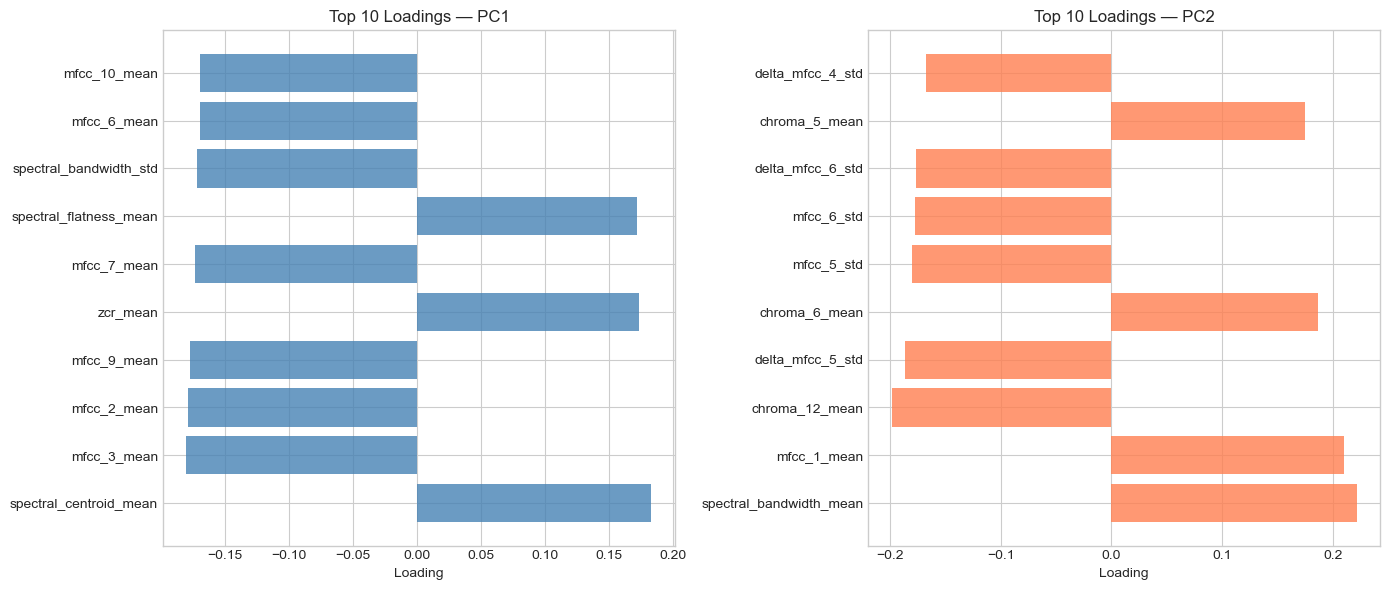

In [17]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — PCA LOADINGS (TOP FEATURES)                                   ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

loadings_df = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"]
)

top_pc1 = loadings_df["PC1"].abs().sort_values(ascending=False).head(10).index
top_pc2 = loadings_df["PC2"].abs().sort_values(ascending=False).head(10).index

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

pc1_vals = loadings_df.loc[top_pc1, "PC1"].sort_values(key=lambda s: s.abs(), ascending=True)
ax1.barh(pc1_vals.index, pc1_vals.values, color='steelblue', alpha=0.8)
ax1.set_title("Top 10 Loadings — PC1")
ax1.set_xlabel("Loading")
ax1.invert_yaxis()

pc2_vals = loadings_df.loc[top_pc2, "PC2"].sort_values(key=lambda s: s.abs(), ascending=True)
ax2.barh(pc2_vals.index, pc2_vals.values, color='coral', alpha=0.8)
ax2.set_title("Top 10 Loadings — PC2")
ax2.set_xlabel("Loading")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# Feature Distributions by Cluster

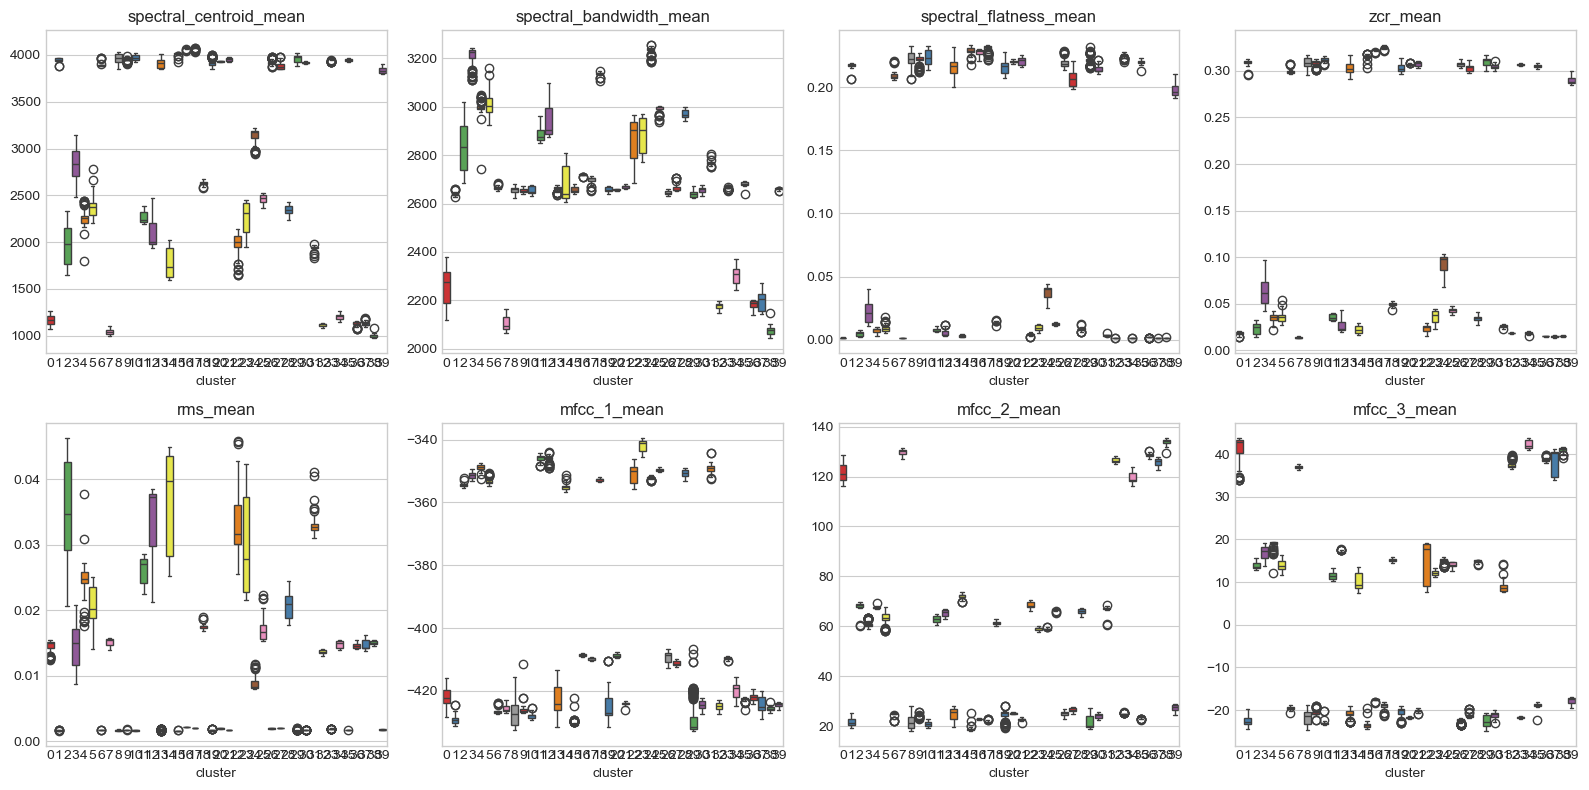

In [18]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — FEATURE DISTRIBUTIONS BY CLUSTER                              ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

df_train["cluster"] = cluster_labels_train

features_to_plot = [
    "spectral_centroid_mean",
    "spectral_bandwidth_mean",
    "spectral_flatness_mean",
    "zcr_mean",
    "rms_mean",
    "mfcc_1_mean",
    "mfcc_2_mean",
    "mfcc_3_mean",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feat in zip(axes, features_to_plot):
    sns.boxplot(data=df_train, x="cluster", y=feat, palette="Set1", ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("cluster")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

# Correlation Heatmap

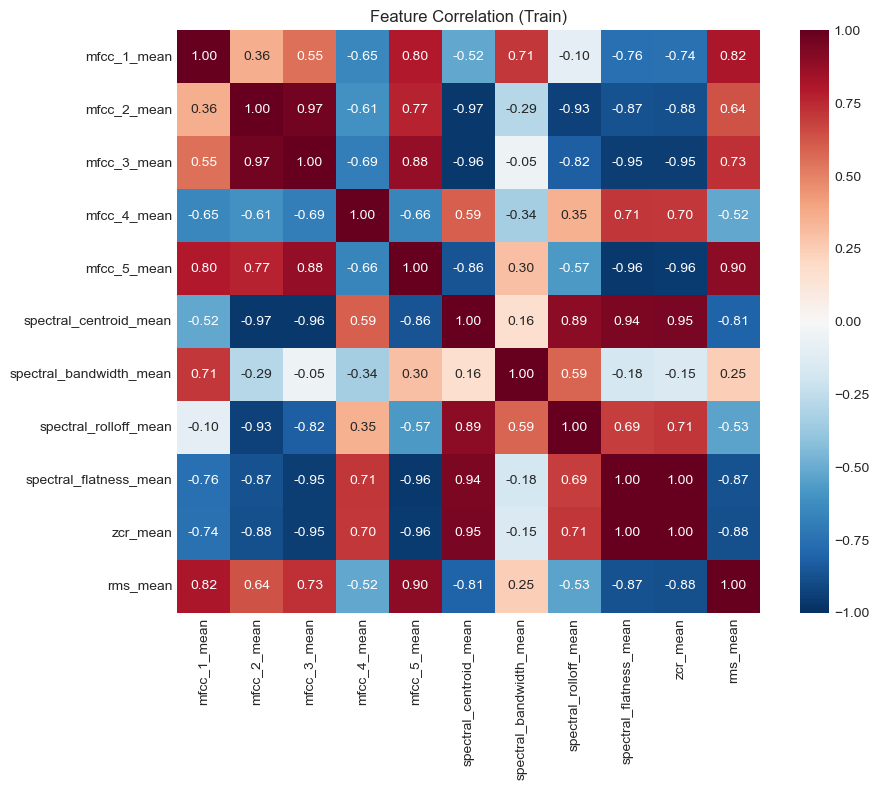

In [19]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — CORRELATION HEATMAP                                           ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

corr_cols = [
    "mfcc_1_mean",
    "mfcc_2_mean",
    "mfcc_3_mean",
    "mfcc_4_mean",
    "mfcc_5_mean",
    "spectral_centroid_mean",
    "spectral_bandwidth_mean",
    "spectral_rolloff_mean",
    "spectral_flatness_mean",
    "zcr_mean",
    "rms_mean",
]

corr = df_train[corr_cols].corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    vmin=-1,
    vmax=1,
)
plt.title("Feature Correlation (Train)")
plt.tight_layout()
plt.show()

# Save Model to disk to be used in HMM notebook

In [21]:
import joblib
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca_2d, "pca_2d.pkl")
joblib.dump(kmeans, "kmeans.pkl")
print("Saved scaler.pkl and pca_2d.pkl")

Saved scaler.pkl and pca_2d.pkl
